In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df_test = pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_23_balm_deployed/final_design_stats.csv")
df_control = pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_24_control_interface_fixing/final_design_stats.csv")
df_small_weight = pd.read_csv("/FastHome/gyula/designs/gy_2nd_iter_try_25_balm_deployed_smaller_weight/final_design_stats.csv")
df_test.loc[:,"condition"] = "BALM guided"
df_control.loc[:,"condition"] = "control"
df_small_weight.loc[:,"condition"] = "small_weight_BALM"

/tmp/ipykernel_3470541/3415109999.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test.loc[:,"condition"] = "BALM guided"
/tmp/ipykernel_3470541/3415109999.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_control.loc[:,"condition"] = "control"
/tmp/ipykernel_3470541/3415109999.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragment

In [21]:
df = pd.concat([df_test, df_control, df_small_weight])

In [22]:
df.loc[:, "Traj_ID"] = df.iloc[:,1].apply(lambda x: x.split("_")[3])

/tmp/ipykernel_3470541/3812741797.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[:, "Traj_ID"] = df.iloc[:,1].apply(lambda x: x.split("_")[3])


In [23]:
avg_by_traj = df.groupby("Traj_ID")["Average_dSASA"].agg("mean")



In [24]:
assert (df.groupby('Traj_ID')['condition'].nunique() == 1).all(), "Some Traj_IDs have mixed conditions"


In [25]:
summary = df.groupby('Traj_ID').agg({
    'Average_dSASA': 'mean',          # Average       # Total
    'condition': 'first',
    "Average_dG" : "mean"    # Multiple operations
})

In [23]:
df.head()

,Rank,Design,Protocol,Length,Seed,Helicity,Target_Hotspot,Sequence,InterfaceResidues,MPNN_score,...,3_Binder_RMSD,4_Binder_RMSD,5_Binder_RMSD,DesignTime,Notes,TargetSettings,Filters,AdvancedSettings,condition,Traj_ID
0,1,BAX_1F16_l18_s748540_mpnn2,4stage,18,748540,0.95,74-99,SMHYIVQETVETLTRVLR,"B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,B12,B13,B14,B15...",0.79,...,NaN,NaN,NaN,"0 hours, 0 minutes, 59 seconds",NaN,settings_bindcraft_2nd_iter,peptide_relaxed_filters,peptide_4stage_multimer_mut_more_iter,BALM guided,s748540
1,2,BAX_1F16_l18_s748540_mpnn1,4stage,18,748540,0.95,74-99,SMHYLVQETVEVLTRVLR,"B1,B2,B3,B4,B5,B6,B8,B9,B10,B12,B13,B14,B15,B1...",0.77,...,NaN,NaN,NaN,"0 hours, 1 minutes, 44 seconds",NaN,settings_bindcraft_2nd_iter,peptide_relaxed_filters,peptide_4stage_multimer_mut_more_iter,BALM guided,s748540
2,3,BAX_1F16_l18_s853072_mpnn2,4stage,18,853072,0.95,74-99,WEWMQKLVQLATEIINSM,"B1,B2,B3,B4,B5,B6,B7,B8,B10,B11,B12,B14,B15,B1...",1.34,...,NaN,NaN,NaN,"0 hours, 0 minutes, 54 seconds",NaN,settings_bindcraft_2nd_iter,peptide_relaxed_filters,peptide_4stage_multimer_mut_more_iter,BALM guided,s853072
3,4,BAX_1F16_l18_s853072_mpnn1,4stage,18,853072,0.95,74-99,WEWMKKLVELATEIINSM,"B1,B2,B3,B4,B6,B7,B8,B10,B11,B12,B14,B15,B18",1.29,...,NaN,NaN,NaN,"0 hours, 1 minutes, 42 seconds",NaN,settings_bindcraft_2nd_iter,peptide_relaxed_filters,peptide_4stage_multimer_mut_more_iter,BALM guided,s853072
4,5,BAX_1F16_l18_s235883_mpnn2,4stage,18,235883,0.95,74-99,INKQGLQEAIDALRKGLS,"B1,B2,B3,B4,B5,B6,B8,B9,B10,B12,B13,B14,B15,B1...",0.73,...,NaN,NaN,NaN,"0 hours, 0 minutes, 59 seconds","Absorption value is 0.0, consider adding trypt...",settings_bindcraft_2nd_iter,peptide_relaxed_filters,peptide_4stage_multimer_mut_more_iter,BALM guided,s235883


<Axes: xlabel='condition', ylabel='Average_dSASA'>

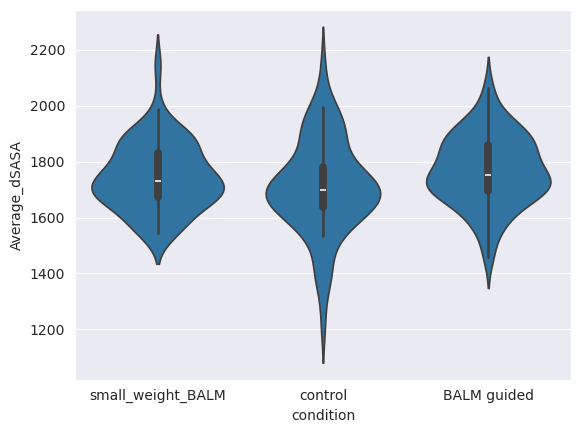

In [29]:
sns.violinplot(summary, x = "condition", y= "Average_dSASA")

In [27]:
from scipy import stats

test_vals = summary.loc[summary['condition'] == 'small_weight_BALM', 'Average_dG']
control_vals = summary.loc[summary['condition'] == 'control', 'Average_dG']

t_stat, p_value = stats.ttest_ind(test_vals, control_vals, equal_var=False, alternative='less')
# 'greater' tests test > control; use 'less' for test < control

print(t_stat, p_value)

-2.7153333207772223 0.0038319997454521167
